# DỰ ÁN AI: PHÂN LOẠI XE ĐẠP VÀ XE MÁY (IMAGE CLASSIFICATION)
Notebook này là "nhà máy" để chế tạo ra trí tuệ nhân tạo.
Mục tiêu: Dạy cho AI biết cách tự động phân biệt đâu là ảnh Xe Đạp (Bike), đâu là ảnh Xe Máy (Motorbike).

*Dành cho người mới học:* Bạn hãy đọc kỹ các ô văn bản (Markdown) trước khi chạy Code nhé. Mã nguồn được chia làm 7 bước theo đúng chuẩn quy trình Machine Learning.

### BƯỚC 1: Chuẩn bị Môi trường và Thư viện
Trong Machine Learning, chúng ta hiếm khi phải tự code toán học từ đầu, thay vào đó ta dùng các "Thư viện" (Libraries) hỗ trợ.
- **PyTorch (`torch`)**: Thư viện nổi tiếng nhất thế giới để xây dựng Trí tuệ nhân tạo Deep Learning.
- **Torchvision**: Thư viện chứa các mô hình xử lý ảnh có sẵn.
- **Kagglehub**: Để tự động tải dữ liệu ảnh từ trên mạng về máy.

*Lưu ý: Chúng ta gọi hàm `set_seed(42)` để khoá "sự ngẫu nhiên" lại. Việc này giúp mỗi lần bạn chạy lại code thì kết quả vẫn giữ nguyên, rất tiện để báo cáo.*

In [1]:
!pip install -q kagglehub seaborn

import os
# Đảm bảo mọi thứ (kể cả dataset) lưu ở thư mục hiện tại
PROJECT_DIR = os.path.abspath(os.getcwd())
os.environ['KAGGLEHUB_CACHE'] = os.path.join(PROJECT_DIR, 'dataset_cache')
import copy
import random
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision.models as tv_models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import kagglehub

# Thiết lập Random Seed để kết quả có thể lặp lại (reproducible)
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# AI sẽ ưu tiên chạy bằng Card màn hình (GPU/CUDA) nếu máy tính bạn có hỗ trợ, nếu không sẽ tự chuyển sang CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Đang sử dụng thiết bị: {device}')

Đang sử dụng thiết bị: cuda


### BƯỚC 2: Thu thập Dữ liệu & Phân chia Tập dữ liệu
Dữ liệu là "thức ăn" của AI. Chúng ta sẽ tải bộ ảnh chứa xe đạp và xe máy về.
Sau đó, chúng ta bắt buộc phải chia số ảnh này làm 3 phần:
1. **Tập Train (Huấn luyện):** Giống như sách giáo khoa để AI ôn bài.
2. **Tập Validation (Kiểm định):** Giống như đề kiểm tra 15 phút, giúp AI tự đánh giá bản thân xem học có vào không.
3. **Tập Test (Thi thật):** Giống như đề thi Đại học, chứa toàn ảnh lạ mà AI chưa từng thấy bao giờ, dùng để đánh giá năng lực thực sự của mô hình ở bước cuối cùng.

In [2]:
# Tải dữ liệu từ Kaggle
path = kagglehub.dataset_download('nqa112/vietnamese-bike-and-motorbike')
print('Đường dẫn tải dataset:', path)

all_image_paths = []
labels = []

# Định nghĩa nhãn: Xe máy = 1, Xe đạp = 0
motor_aliases = ['motorbike', 'motor', 'xe may', 'xe_may']
bike_aliases = ['bike', 'xe dap', 'xe_dap', 'bicycle']

# Lọc các file ảnh từ thư mục tải về
for root, _, files in os.walk(path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.webp', '.bmp')):
            full_path = os.path.join(root, file)
            rel_path = os.path.relpath(full_path, path).lower()
            
            is_motor = any(alias in rel_path for alias in motor_aliases)
            is_bike = any(alias in rel_path for alias in bike_aliases)
            
            if is_motor:
                all_image_paths.append(full_path)
                labels.append(1)
            elif is_bike:
                all_image_paths.append(full_path)
                labels.append(0)

class_names = ['Bike', 'Motorbike']
print(f'Tổng số ảnh thu thập được: {len(all_image_paths)}')

# Tiến hành chia tỷ lệ dữ liệu: 64% Train - 16% Validation - 20% Test
trainval_paths, test_paths, trainval_labels, test_labels = train_test_split(
    all_image_paths, labels, test_size=0.2, stratify=labels, random_state=42
)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    trainval_paths, trainval_labels, test_size=0.2, stratify=trainval_labels, random_state=42
)

print(f'Tập Train: {len(train_paths)} ảnh, Tập Validation: {len(val_paths)} ảnh, Tập Test: {len(test_paths)} ảnh')

100%|██████████| 1.44G/1.44G [00:12<00:00, 126MB/s] 


Extracting files...
Đường dẫn tải dataset: /content/dataset_cache/datasets/nqa112/vietnamese-bike-and-motorbike/versions/1
Tổng số ảnh thu thập được: 12118
Tập Train: 7755 ảnh, Tập Validation: 1939 ảnh, Tập Test: 2424 ảnh


### BƯỚC 3: Tiền xử lý Dữ liệu (Data Augmentation) & Khởi tạo DataLoader
**Data Augmentation là gì?**
Nếu AI chỉ học đi học lại một bức ảnh giống hệt nhau, nó sẽ mắc bệnh **"Học vẹt" (Overfitting)**. Lên thực tế thấy cái xe bị chụp ngược sáng là nó không nhận ra.
Vì vậy, với tập Train, ta áp dụng kỹ thuật *Augmentation* (Xoay ảnh 1 chút, lật ngang ảnh, đổi độ sáng...) để AI linh hoạt hơn.

Đối với tập Val và Test, ta giữ nguyên gốc (chỉ Resize về kích thước 224x224) vì đây là lúc thi thật, không được phép "biến tấu" đề thi.

In [3]:
# Thông số tiêu chuẩn khi dùng các mô hình ảnh của PyTorch
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Biến tấu ảnh cho tập Train (Giúp mô hình học chống Overfitting)
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), # Cắt ngẫu nhiên và đưa về chuẩn 224x224
    transforms.RandomRotation(10),                       # Xoay tối đa 10 độ
    transforms.RandomHorizontalFlip(),                   # Lật ngang ngẫu nhiên
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Đổi màu/độ sáng
    transforms.ToTensor(),                               # Biến đổi ảnh thành ma trận số học (Tensor)
    transforms.Normalize(mean, std)                      # Chuẩn hoá màu sắc
])

# Tập Test & Val chỉ cần Resize về chuẩn, không được phép làm biến dạng ảnh
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Định nghĩa cấu trúc Dataset
class BikeMotorbikeDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
        
    def __getitem__(self, idx):
        path = self.image_paths[idx]
        try:
            image = Image.open(path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224), (0, 0, 0)) # Tạo ảnh đen nếu ảnh bị hỏng
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label, path

# Khởi tạo các DataLoader (Băng chuyền tự động đẩy dữ liệu vào mô hình theo từng "Lô" - batch_size)
train_dataset = BikeMotorbikeDataset(train_paths, train_labels, transform=train_transforms)
val_dataset = BikeMotorbikeDataset(val_paths, val_labels, transform=val_test_transforms)
test_dataset = BikeMotorbikeDataset(test_paths, test_labels, transform=val_test_transforms)

batch_size = 32
num_workers = 2 
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

### BƯỚC 4: Khởi tạo Mô hình (Transfer Learning) & Hàm Huấn luyện
Để giải bài toán này, thay vì xây một mô hình AI mới từ con số 0 (sẽ mất cực kỳ nhiều thời gian), ta áp dụng kỹ thuật **Học Chuyển Giao (Transfer Learning)**.

Ta sử dụng **ResNet50** - một siêu mô hình đã được huấn luyện trên 1.2 triệu bức ảnh (ImageNet). Nó đã có sẵn "tư duy" nhận biết các đường nét cơ bản (góc cạnh, hình khối).
Công việc của chúng ta chỉ đơn giản là: "Cắt bỏ lớp phân loại 1000 đồ vật của ResNet50 đi, gắn một lớp phân loại mới (chỉ phân biệt 2 thứ là Xe đạp / Xe máy) vào, và huấn luyện lại một chút xíu".

In [4]:
def train_model(model, criterion, optimizer, num_epochs=10, history=None):
    if history is None:
        history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
        
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        
        # Mô hình có 2 trạng thái: 'train' (để học) và 'val' (để thi thử)
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
                dataset_size = len(train_dataset)
            else:
                model.eval()
                dataloader = val_loader
                dataset_size = len(val_dataset)

            running_loss = 0.0
            running_corrects = 0

            # Lặp qua từng "lô" (batch) ảnh
            for inputs, labels, _ in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad() # Xoá bộ nhớ tính toán cũ
                
                # Bật tính năng cập nhật trọng số (Học) nếu đang ở tập Train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels) # Tính toán độ sai lệch (Loss)

                    if phase == 'train':
                        loss.backward()  # Truyền ngược sai số
                        optimizer.step() # Cập nhật trọng số (Não bộ AI thay đổi)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # Đánh giá kết quả của 1 Epoch
            epoch_loss = running_loss / dataset_size
            epoch_acc = running_corrects.double() / dataset_size
            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Lưu vào lịch sử để tí nữa vẽ biểu đồ
            if phase == 'train':
                history['train_loss'].append(float(epoch_loss))
                history['train_acc'].append(float(epoch_acc))
            else:
                history['val_loss'].append(float(epoch_loss))
                history['val_acc'].append(float(epoch_acc))

            # [CƠ CHẾ MODEL CHECKPOINTING]
            # Nếu điểm thi thử (val_acc) cao hơn lịch sử thì tự động sao lưu lại trọng số (Não bộ) lúc này.
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                
    # Sau khi chạy hết các Epochs, nạp lại bộ não thông minh nhất từng có
    model.load_state_dict(best_model_wts)
    return model, history

# Tải siêu mô hình ResNet50 (Kèm theo trọng số đã được học sẵn từ ImageNet)
weights = tv_models.ResNet50_Weights.IMAGENET1K_V1
model = tv_models.resnet50(weights=weights)

# Cắt bỏ layer cuối cùng (Vốn dĩ ra 1000 kết quả), thay bằng Layer mới chỉ ra 2 kết quả (Bike và Motorbike)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model = model.to(device)

# Hàm đánh giá lỗi - CrossEntropyLoss (Chuyên dùng cho bài toán Classification)
criterion = nn.CrossEntropyLoss()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 184MB/s]


### BƯỚC 5: Thực thi Quá trình Huấn luyện (2 Giai đoạn)
Mẹo hay nhất để làm Transfer Learning là chia làm 2 giai đoạn:
- **Giai đoạn 1 (Train layer cuối):** Ta sẽ khoá băng (freeze) các nơ-ron nhận diện góc cạnh của ResNet50 lại để bảo vệ chúng khỏi bị "sốc kiến thức", ta chỉ dạy cho riêng layer cuối cùng nhận biết xe đạp/xe máy (5 Epochs).
- **Giai đoạn 2 (Fine-Tuning toàn bộ):** Sau khi layer cuối đã "quen việc", ta mở khoá (unfreeze) toàn bộ mô hình và dùng tốc độ học (`learning rate`) thật nhỏ để cả mạng AI tinh chỉnh lại một cách mượt mà nhất (15 Epochs).

In [5]:
# Chỉ chạy huấn luyện nếu chưa có best_model.pth (Hoặc bạn có thể xóa file đó trong folder để train lại)
if not os.path.exists(os.path.join(PROJECT_DIR, 'best_model.pth')):
    print('=== BẮT ĐẦU GIAI ĐOẠN 1 (Train layer cuối) ===')
    
    # Khoá (Freeze) các lớp cũ
    for param in model.parameters(): param.requires_grad = False
    # Mở khoá (Unfreeze) lớp cuối cùng
    for param in model.fc.parameters(): param.requires_grad = True
    
    optimizer_ft_1 = optim.Adam(model.fc.parameters(), lr=1e-3) # Learning rate lớn để layer mới học nhanh
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    model, history = train_model(model, criterion, optimizer_ft_1, num_epochs=5, history=history)

    print('\n=== BẮT ĐẦU GIAI ĐOẠN 2 (Fine-tuning toàn bộ) ===')
    # Mở khoá toàn bộ mạng
    for param in model.parameters(): param.requires_grad = True
    
    optimizer_ft_2 = optim.Adam(model.parameters(), lr=1e-4) # Learning rate nhỏ để từ từ tinh chỉnh tổng thể
    model, history = train_model(model, criterion, optimizer_ft_2, num_epochs=15, history=history)

    # LƯU KẾT QUẢ CUỐI CÙNG VÀO Ổ CỨNG
    torch.save(model.state_dict(), os.path.join(PROJECT_DIR, 'best_model.pth'))
    print('Đã lưu trọng số mô hình tại best_model.pth')
    
    with open(os.path.join(PROJECT_DIR, 'training_history.json'), 'w') as f:
        json.dump(history, f)
    print('Đã lưu lịch sử huấn luyện tại training_history.json')
else:
    print('Đã tìm thấy bộ não "best_model.pth" từ lần học trước, bỏ qua quá trình huấn luyện!')
    print('Mời chạy Cell tiếp theo để vẽ biểu đồ.')

=== BẮT ĐẦU GIAI ĐOẠN 1 (Train layer cuối) ===
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.1449 Acc: 0.9509


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Val Loss: 0.0463 Acc: 0.9850
Epoch 2/5


...

Val Loss: 0.0212 Acc: 0.9907
Epoch 15/15


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.0080 Acc: 0.9973


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Val Loss: 0.0139 Acc: 0.9964
Đã lưu trọng số mô hình tại best_model.pth
Đã lưu lịch sử huấn luyện tại training_history.json


### BƯỚC 6: Trực quan hoá quá trình học (Vẽ biểu đồ Loss & Accuracy) + Đánh dấu Early Stopping
Phần này sẽ vẽ lại toàn bộ quá trình học để người xem có thể đánh giá xem AI tiến bộ như thế nào.

**Lưu ý cực hay (Early Stopping):** 
Trong lúc huấn luyện, ta ép AI học đủ 20 Epochs. Tuy nhiên, ở Cell này, mình có lồng thêm một đoạn logic phân tích biểu đồ (Giả lập Early Stopping). Nó sẽ tự động rà soát xem ở Epoch nào thì điểm Lỗi của bộ Test (`Val Loss`) ngưng cải thiện (bão hoà) trong 3 vòng liên tiếp (`patience=3`). 
Vị trí đó chính là "Toạ độ vàng" mà lẽ ra ta nên chủ động ngắt AI ngay lập tức để tiết kiệm điện năng và tránh bị Overfitting.

---> LƯU Ý KHI BÁO CÁO: Nếu bật cơ chế Early Stopping thực sự, mô hình có thể đã tự ngắt tại Epoch 14 do val_loss không cải thiện trong 3 vòng liên tiếp.

Đã lưu biểu đồ vào file loss_accuracy_plot.png


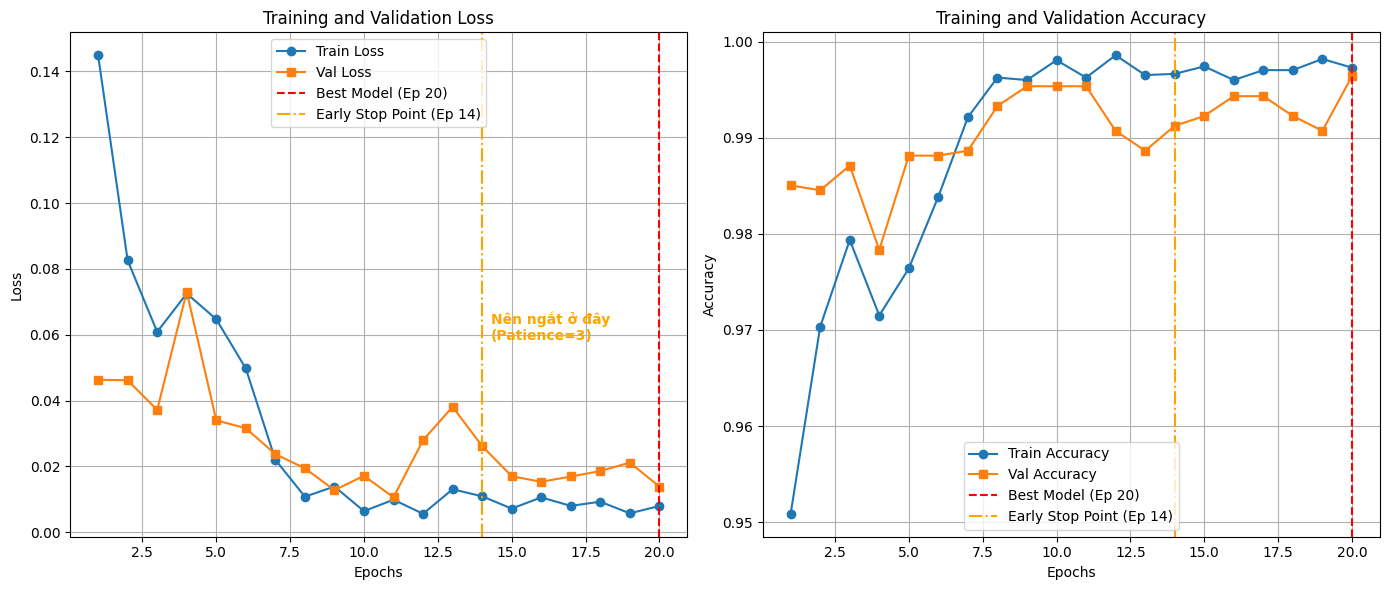

In [6]:
# Vẽ biểu đồ dựa trên lịch sử đã lưu
if os.path.exists(os.path.join(PROJECT_DIR, 'training_history.json')):
    with open(os.path.join(PROJECT_DIR, 'training_history.json'), 'r') as f:
        history = json.load(f)
        
    train_loss = history['train_loss']
    val_loss = history['val_loss']
    train_acc = history['train_acc']
    val_acc = history['val_acc']
    epochs = range(1, len(train_loss) + 1)
    
    # 1. Tự động tìm ra Epoch có Validation Accuracy cao nhất (Chính là Best Model được lưu lại)
    best_epoch = val_acc.index(max(val_acc)) + 1
    
    # 2. Giả lập cơ chế Early Stopping (Dựa trên Validation Loss)
    patience = 3 # Định nghĩa: Nếu 3 epochs liên tiếp val_loss không giảm thì ngắt
    best_loss = float('inf')
    wait = 0
    early_stop_epoch = None
    
    for i, loss in enumerate(val_loss):
        if loss < best_loss:
            best_loss = loss
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                early_stop_epoch = i + 1
                print(f"---> LƯU Ý KHI BÁO CÁO: Nếu bật cơ chế Early Stopping thực sự, mô hình có thể đã tự ngắt tại Epoch {early_stop_epoch} do val_loss không cải thiện trong {patience} vòng liên tiếp.")
                break
                
    # === Bắt đầu vẽ ===
    plt.figure(figsize=(14, 6))
    
    # --- Biểu đồ Loss ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, 'o-', label='Train Loss')
    
    # Do cách setup cũ chia lịch sử train/val nên ta chỉnh để vẽ đè lên nhau chuẩn
    val_epochs = np.linspace(1, len(train_loss), len(val_loss)) if len(val_loss) != len(train_loss) else epochs
    plt.plot(val_epochs, val_loss, 's-', label='Val Loss')
    
    # Đánh dấu Best Model bằng đường dọc đỏ
    plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Model (Ep {best_epoch})')
    
    # Đánh dấu "Toạ độ vàng" của Early Stop bằng đường dọc cam
    if early_stop_epoch:
        plt.axvline(x=early_stop_epoch, color='orange', linestyle='-.', label=f'Early Stop Point (Ep {early_stop_epoch})')
        plt.text(early_stop_epoch + 0.3, max(val_loss)*0.8, f"Nên ngắt ở đây\n(Patience={patience})", color='orange', fontweight='bold')

    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # --- Biểu đồ Accuracy ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, 'o-', label='Train Accuracy')
    plt.plot(val_epochs, val_acc, 's-', label='Val Accuracy')
    
    plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Model (Ep {best_epoch})')
    if early_stop_epoch:
        plt.axvline(x=early_stop_epoch, color='orange', linestyle='-.', label=f'Early Stop Point (Ep {early_stop_epoch})')

    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_DIR, 'loss_accuracy_plot.png'), dpi=300)
    print('\nĐã lưu biểu đồ vào file loss_accuracy_plot.png')
    plt.show()
else:
    print('Chưa có lịch sử huấn luyện. Hãy chạy cell huấn luyện trước.')

### BƯỚC 7: Kiểm định lại trên tập "Thi Thật" (Test Set)
Trong khoa học dữ liệu, chỉ điểm thi thử (Val Accuracy) cao là chưa đủ.
Ta sẽ nạp file `best_model.pth` vừa được chọn ra và cho chạy qua Tập Test (chứa 20% dữ liệu mà AI chưa từng được thấy trong suốt quá trình luyện tập).

**Confusion Matrix (Ma trận nhầm lẫn)** ở cuối sẽ giúp bạn nhìn cực rõ: AI đã dự đoán chuẩn Bike bao nhiêu lần, nhầm thành Motorbike bao nhiêu lần, và ngược lại.

Đã lắp thành công "não bộ" best_model.pth vào AI

Đang tiến hành chấm bài thi trên tập Test Set...


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



=== BẢNG ĐIỂM (CLASSIFICATION REPORT) ===
              precision    recall  f1-score   support

        Bike     0.9950    0.9959    0.9955      1209
   Motorbike     0.9959    0.9951    0.9955      1215

    accuracy                         0.9955      2424
   macro avg     0.9955    0.9955    0.9955      2424
weighted avg     0.9955    0.9955    0.9955      2424

Tổng Điểm Thi Thật (Test Accuracy): 99.55%


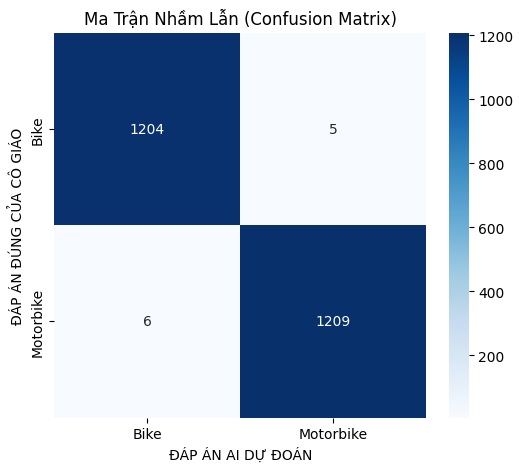

Đã lưu biểu đồ vào máy tính!


In [7]:
# Tải lại bộ não (trọng số) xịn nhất vào Mô hình trước khi đem đi Thi thật
if os.path.exists(os.path.join(PROJECT_DIR, 'best_model.pth')):
    model.load_state_dict(torch.load(os.path.join(PROJECT_DIR, 'best_model.pth'), map_location=device, weights_only=True))
    print('Đã lắp thành công "não bộ" best_model.pth vào AI')
else:
    print('CẢNH BÁO: Không tìm thấy best_model.pth, đang dùng bộ nhớ tạm thời của model (có thể sai lệch).')

print('\nĐang tiến hành chấm bài thi trên tập Test Set...')
model.eval() # Bật chế độ Làm bài thi (Không học hỏi thêm gì nữa)

y_true = [] # Chứa đáp án chính xác
y_pred = [] # Chứa đáp án do AI đoán

with torch.no_grad(): # Tắt truyền ngược đạo hàm để tiết kiệm RAM (vì không cần cập nhật trọng số)
    for inputs, labels, paths in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)            # AI làm bài
        _, preds = torch.max(outputs, 1)   # Chọn ra đáp án tự tin nhất
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# In Bảng điểm chi tiết
print('\n=== BẢNG ĐIỂM (CLASSIFICATION REPORT) ===')
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
acc_text = f'Tổng Điểm Thi Thật (Test Accuracy): {accuracy_score(y_true, y_pred)*100:.2f}%'
print(report)
print(acc_text)

# Lưu log kết quả thành file txt 
with open(os.path.join(PROJECT_DIR, 'training_results.txt'), 'w', encoding='utf-8') as f:
    f.write('=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ===\n')
    f.write(report + '\n')
    f.write(acc_text + '\n')

# Vẽ Ma Trận Nhầm Lẫn (Confusion Matrix)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Ma Trận Nhầm Lẫn (Confusion Matrix)')
plt.ylabel('ĐÁP ÁN ĐÚNG CỦA CÔ GIÁO')
plt.xlabel('ĐÁP ÁN AI DỰ ĐOÁN')
plt.savefig(os.path.join(PROJECT_DIR, 'confusion_matrix.png'), dpi=300)
plt.show()
print('Đã lưu biểu đồ vào máy tính!')